#**Assignment 4**
####**Fehime CAPAR | 605437**

# **1. Cluster Analysis**

# **1.1. kMeans / kModes / kPrototypes Clustering**

# Load data and select features

In [1]:
!pip -q install kmodes openpyxl

In [2]:
import io, sys, math, warnings
from kmodes.kprototypes import KPrototypes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics.cluster import contingency_matrix
import warnings

warnings.filterwarnings('ignore')

# Opsiyonel paketler
try:
    import hdbscan
except Exception:
    hdbscan = None
try:
    from kmodes.kprototypes import KPrototypes
except Exception:
    KPrototypes = None
try:
    import prince
except Exception:
    prince = None
try:
    import gower
except Exception:
    gower = None

sns.set(style='whitegrid')

In [3]:
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 120
plt.style.use("seaborn-v0_8")

In [5]:
# 1) Load dataset
file_path = '/content/21_Fish_market_regression.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

print(df.shape)
display(df.head())
display(df.describe(include='all'))
print('Columns:', df.columns.tolist())

(159, 7)


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


,Species,Weight,Length1,Length2,Length3,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500


Columns: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']


In [9]:
target_col = 'Weight'
cat_cols = ['Species']
num_cols = [c for c in df.columns if c not in cat_cols + [target_col]]

# X (features), Y (regression) ve sınıf etiketleri (dış metrikler için)
X_mix = df[cat_cols + num_cols].copy()
y_reg = df[target_col].values
limit_value = float(np.median(y_reg))
y_cls = np.where(y_reg < limit_value, 1, 2)
print(f'limit_value (Weight median): {limit_value:.3f}')

num_transform = Pipeline([('imp', SimpleImputer(strategy='mean')), ('sc', StandardScaler())])
X_num_scaled = num_transform.fit_transform(df[num_cols])
# One-hot + numerical (Ward and some metrics)
cat_transform = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
pre_full = ColumnTransformer([('num', num_transform, num_cols), ('cat', cat_transform, cat_cols)])
X_full = pre_full.fit_transform(X_mix)

# Gower distance (mixed dataset)
def gower_distance_manual(df_mix, cat_cols, num_cols):
    A = df_mix.copy()
    A_cat = A[cat_cols].astype('category')
    A_num = A[num_cols].astype(float).copy()
    mins = A_num.min(axis=0); maxs = A_num.max(axis=0)
    ranges = (maxs - mins).replace(0, 1.0)
    A_num_norm = (A_num - mins) / ranges
    Xn = A_num_norm.values; N = Xn.shape[0]
    dists_num = np.zeros((N,N))
    if Xn.shape[1] > 0:
        for i in range(N):
            dists_num[i] = np.abs(Xn[i] - Xn).mean(axis=1)
    dists_cat = np.zeros((N,N))
    if len(cat_cols) > 0:
        Xc = np.column_stack([A_cat[c].cat.codes.values for c in cat_cols])
        for i in range(N):
            dists_cat[i] = (Xc[i] != Xc).mean(axis=1)
    if (Xn.shape[1] > 0) and (len(cat_cols)>0):
        return 0.5*dists_num + 0.5*dists_cat
    return dists_num if Xn.shape[1]>0 else dists_cat

def compute_gower_matrix(df_in, cat_cols, num_cols):
    try:
        import gower as _g
        return _g.gower_matrix(df_in[cat_cols + num_cols])
    except Exception:
        return gower_distance_manual(df_in[cat_cols + num_cols], cat_cols, num_cols)


limit_value (Weight median): 273.000


In [7]:
# column
df.columns = [str(c).strip() for c in df.columns]

# check
print(df.head(3))
print(df.dtypes)
print(df.isna().sum())

  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
Species     object
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object
Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64


In [10]:
# - categorical: 'Species'
# - numerical:   'Length1','Length2','Length3','Height','Width'
# - target:     'Weight'  -> use for clustering
CAT_COLS = ["Species"]
NUM_COLS = ["Length1", "Length2", "Length3", "Height", "Width"]

# No NaN data:
if df[CAT_COLS + NUM_COLS].isna().any().any():
    raise ValueError("Nan Value.")

scaler = StandardScaler()
X_num = scaler.fit_transform(df[NUM_COLS].values.astype(float))

X_mixed = np.concatenate([X_num.astype(float), X_cat], axis=1)

cat_idx_start = len(NUM_COLS)
CATEGORICAL_INDICES = list(range(cat_idx_start, cat_idx_start + len(CAT_COLS)))

print(f"Mixed matrix form: {X_mixed.shape} | Categorical column indexes: {CATEGORICAL_INDICES}")

Mixed matrix form: (159, 6) | Categorical column indexes: [5]


k= 2 -> cost=336.47
k= 3 -> cost=262.47
k= 4 -> cost=175.05
k= 5 -> cost=135.24
k= 6 -> cost=106.18
The best one chosen intuitively: 5
Ward (full) -> k = 5 | labels_ward shape: (159,)


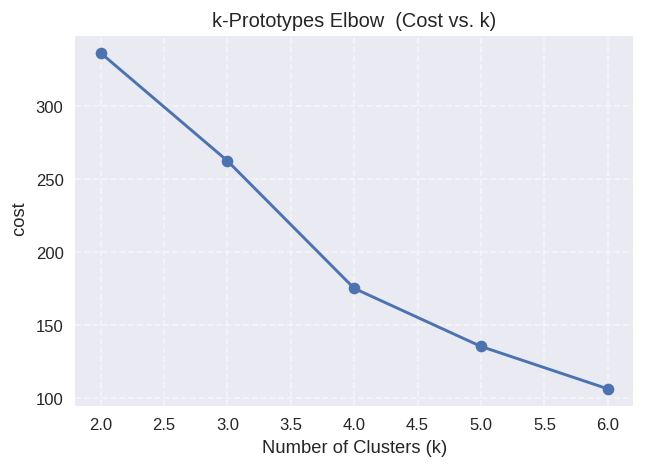

In [71]:
# 4) Elbow: k-Prototypes cost vs. k
def kprototypes_elbow(X, categorical_indices, k_min=2, k_max=10, n_init=10, max_iter=100, init="Huang", random_state=RANDOM_STATE, verbose=0, gamma=None):
    """
    Calculates the k-Prototypes cost_ values ​​based on k values.
    gamma: Relative weight of numerical and categorical distances. None -> kmodes uses its own heuristic.
    """
    costs, models = [], []
    ks = list(range(k_min, k_max + 1))
    for k in ks:
        kp = KPrototypes(
            n_clusters=k,
            init=init,
            n_init=n_init,
            max_iter=max_iter,
            verbose=verbose,
            random_state=random_state,
            gamma=gamma
        )
        # fit_predict: returns the labels, cost_ is stored in the model.
        _ = kp.fit_predict(X, categorical=categorical_indices)
        costs.append(kp.cost_)
        models.append(kp)
        print(f"k={k:2d} -> cost={kp.cost_:,.2f}")
    return ks, costs, models

ks, costs, models = kprototypes_elbow(
    X_mixed, CATEGORICAL_INDICES,
    k_min=2, k_max=6, # Reduced k_max from 10 to 6
    n_init=10, max_iter=100, init="Cao", random_state=RANDOM_STATE # Changed init to "Cao"
)

def find_elbow_k(ks, costs):
    # The second difference of the costs series (captures the approximate curve break)
    if len(costs) < 3:
        return ks[np.argmin(costs)]
    second_diff = np.diff(costs, n=2)  # len = len(costs) - 2
    idx = int(np.argmax(np.abs(second_diff)))
    return ks[idx + 2]  # The second difference index is converted to k by adding +2.

best_k = find_elbow_k(ks, costs)
print(f"The best one chosen intuitively: {best_k}")

X_kp = df[CAT_COLS + NUM_COLS].copy()
cat_idx = [X_kp.columns.get_loc(c) for c in CAT_COLS]

kp_best = KPrototypes(n_clusters=best_k, init='Huang', random_state=42)
labels_kp = kp_best.fit_predict(X_kp.values, categorical=cat_idx)

# Ward (complete space, OHE+Scaled Euclidean)

# Ward linkage (hierarchical) and cluster segmentation: k = best_k
Z_ward_full = linkage(X_num, method='ward')
labels_ward = fcluster(Z_ward_full, t=best_k, criterion='maxclust') - 1

print("Ward (full) -> k =", best_k, "| labels_ward shape:", labels_ward.shape)

# Elbow
plt.figure(figsize=(6,4))
plt.plot(ks, costs, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel(" cost")
plt.title("k‑Prototypes Elbow  (Cost vs. k)")
plt.grid(True, ls="--", alpha=0.5)
plt.show()

In [12]:
# 5) model and output
# Get the best model with best_k
kp_best = models[ks.index(best_k)]
labels = kp_best.labels_.astype(int)

# Result DataFrame: (original index + selected attributes + cluster label)
result_cols = CAT_COLS + NUM_COLS
result_df = df[result_cols].copy()
result_df["cluster"] = labels

# size
cluster_sizes = result_df["cluster"].value_counts().sort_index()
print("cluster sizes:\n", cluster_sizes)

result_df.head(10)


cluster sizes:
 cluster
0    33
1     6
2    21
3    65
4    34
Name: count, dtype: int64


,Species,Length1,Length2,Length3,Height,Width,cluster
0,Bream,23.2,25.4,30.0,11.5200,4.0200,3
1,Bream,24.0,26.3,31.2,12.4800,4.3056,4
2,Bream,23.9,26.5,31.1,12.3778,4.6961,4
3,Bream,26.3,29.0,33.5,12.7300,4.4555,4
4,Bream,26.5,29.0,34.0,12.4440,5.1340,4
5,Bream,26.8,29.7,34.7,13.6024,4.9274,4
6,Bream,26.8,29.7,34.5,14.1795,5.2785,4
7,Bream,27.6,30.0,35.0,12.6700,4.6900,4
8,Bream,27.6,30.0,35.1,14.0049,4.8438,4
9,Bream,28.5,30.7,36.2,14.2266,4.9594,4


# **1.2. Hierarchical Clustering**

In [13]:
from itertools import combinations
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score

In [14]:
# ---------- Utilities ----------
def gower_condensed(df_in: pd.DataFrame, num_cols, cat_cols):
    """
    Compute Gower condensed distance vector for mixed-type data.
    - Numeric columns: min-max normalization, L1 difference normalized by range
    - Categorical columns: 0 if match else 1
    Returns: condensed distance (1D array of length n*(n-1)/2)
    """
    Xn = df_in[num_cols].to_numpy(float) if len(num_cols) else np.empty((len(df_in), 0))
    Xc = df_in[cat_cols].astype("object").to_numpy() if len(cat_cols) else np.empty((len(df_in), 0), dtype=object)

    n = len(df_in)
    # Min-max normalization for numeric
    if Xn.shape[1] > 0:
        min_, max_ = Xn.min(axis=0), Xn.max(axis=0)
        rng = np.where((max_ - min_) == 0, 1.0, (max_ - min_))
        Xn = (Xn - min_) / rng

    m_num, m_cat = Xn.shape[1], Xc.shape[1]
    m_total = m_num + m_cat if (m_num + m_cat) > 0 else 1

    dists = np.empty(n*(n-1)//2, dtype=float)
    k = 0
    for i in range(n-1):
        # numeric part
        if m_num:
            num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1)
        else:
            num_diff = 0.0
        # categorical part
        if m_cat:
            cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1)
        else:
            cat_diff = 0.0

        s = (num_diff + cat_diff) / m_total
        dists[k:k+len(s)] = s
        k += len(s)
    return dists

In [15]:
def condensed_to_square(dists, n):
    return squareform(dists)

def pick_k_by_silhouette_from_Z(Z, X_or_D, metric, k_range=range(2, 11)):
    """
    Choose k using silhouette score.
    - For Gower: metric='precomputed' with full distance matrix (square)
    - For Ward (OHE): metric='euclidean' with feature matrix
    """
    best = {"k": None, "score": -1, "labels": None}
    for k in k_range:
        labels = fcluster(Z, k, criterion="maxclust")
        if metric == "precomputed":
            score = silhouette_score(X_or_D, labels, metric="precomputed")
        else:
            score = silhouette_score(X_or_D, labels, metric=metric)
        if score > best["score"]:
            best = {"k": k, "score": float(score), "labels": labels}
    return best

In [16]:
# ---------- Build inputs ----------
# We will use NUM_COLS + CAT_COLS; target 'Weight' is excluded (unsupervised).
mix_cols = NUM_COLS + CAT_COLS
D_gower_cond = gower_condensed(df[mix_cols], NUM_COLS, CAT_COLS)   # condensed (1D)
Z_gower_avg = linkage(D_gower_cond, method="average")               # average linkage on precomputed distances
Z_gower_com = linkage(D_gower_cond, method="complete")              # complete linkage on precomputed distances

# For Ward's method we need Euclidean on features -> One-Hot encode categorical
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_ohe = ohe.fit_transform(df[CAT_COLS])
# Reuse standardized numerics from Step 1.1: X_num
X_ward = np.hstack([X_num, X_cat_ohe])  # Euclidean-friendly feature space
Z_ward = linkage(X_ward, method="ward")

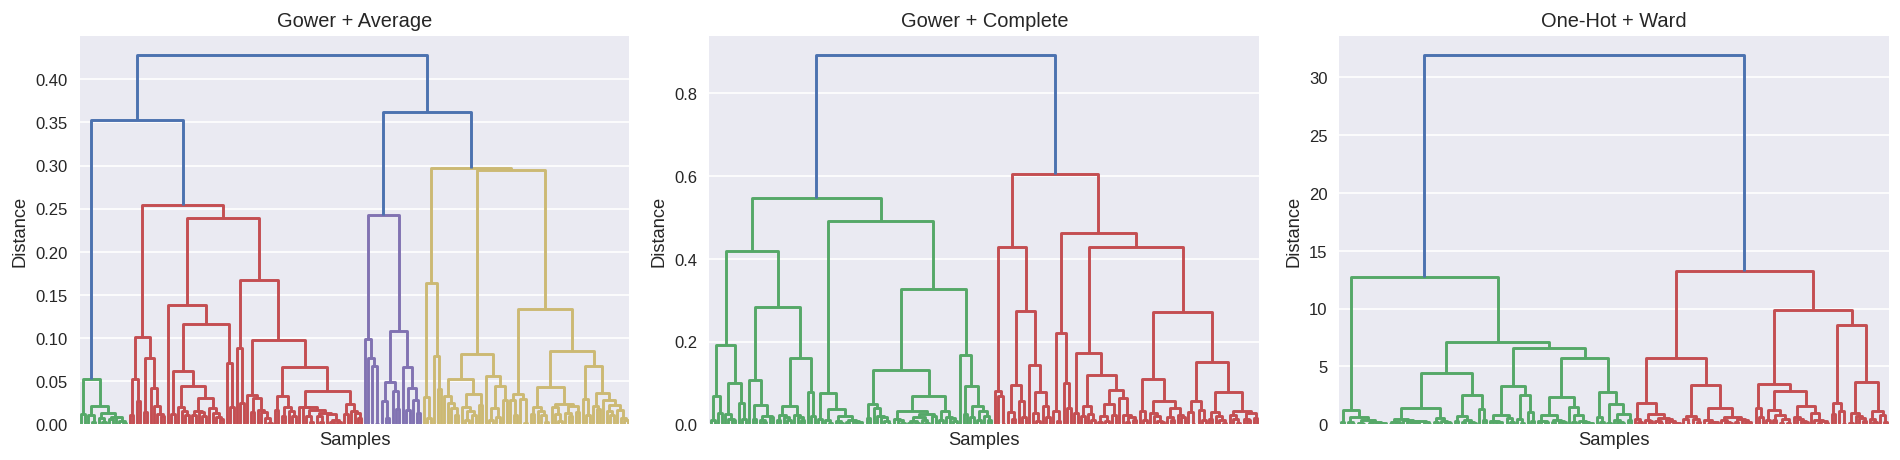

In [17]:
# ---------- Dendrograms ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, Z, title in zip(
    axes,
    [Z_gower_avg, Z_gower_com, Z_ward],
    ["Gower + Average", "Gower + Complete", "One-Hot + Ward"]
):
    dendrogram(Z, no_labels=True, color_threshold=None, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Samples")
    ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

In [18]:
# ---------- Recommended k via Silhouette ----------
# For Gower we need the full (square) distance matrix for silhouette with 'precomputed'
D_gower_sq = condensed_to_square(D_gower_cond, len(df))

best_avg   = pick_k_by_silhouette_from_Z(Z_gower_avg, D_gower_sq, metric="precomputed")
best_com   = pick_k_by_silhouette_from_Z(Z_gower_com, D_gower_sq, metric="precomputed")
best_ward  = pick_k_by_silhouette_from_Z(Z_ward, X_ward,       metric="euclidean")

print("Recommended k (by silhouette):")
print(f"- Gower + Average : k={best_avg['k']} | silhouette={best_avg['score']:.3f}")
print(f"- Gower + Complete: k={best_com['k']} | silhouette={best_com['score']:.3f}")
print(f"- One-Hot + Ward  : k={best_ward['k']} | silhouette={best_ward['score']:.3f}")


Recommended k (by silhouette):
- Gower + Average : k=9 | silhouette=0.703
- Gower + Complete: k=9 | silhouette=0.698
- One-Hot + Ward  : k=10 | silhouette=0.503


In [19]:
# ---------- Final cluster assignments as DataFrames ----------
base_cols = CAT_COLS + NUM_COLS
df_hc_avg = df[base_cols].copy()
df_hc_com = df[base_cols].copy()
df_hc_wrd = df[base_cols].copy()

df_hc_avg["cluster_gower_avg"]   = best_avg["labels"]
df_hc_com["cluster_gower_comp"]  = best_com["labels"]
df_hc_wrd["cluster_ohe_ward"]    = best_ward["labels"]

In [20]:
# Show quick summaries
print("\nCluster sizes (Gower+Average):")
print(df_hc_avg["cluster_gower_avg"].value_counts().sort_index())
print("\nCluster sizes (Gower+Complete):")
print(df_hc_com["cluster_gower_comp"].value_counts().sort_index())
print("\nCluster sizes (OHE+Ward):")
print(df_hc_wrd["cluster_ohe_ward"].value_counts().sort_index())


Cluster sizes (Gower+Average):
cluster_gower_avg
1    14
2    11
3    20
4    37
5     5
6    12
7     6
8    19
9    35
Name: count, dtype: int64

Cluster sizes (Gower+Complete):
cluster_gower_comp
1    11
2    20
3    14
4    37
5     4
6    13
7     6
8    19
9    35
Name: count, dtype: int64

Cluster sizes (OHE+Ward):
cluster_ohe_ward
1     14
2     29
3     14
4     17
5     11
6     14
7     21
8     22
9      5
10    12
Name: count, dtype: int64


In [21]:
# Peek first rows
df_hc_avg.head(10), df_hc_com.head(10), df_hc_wrd.head(10)

(  Species  Length1  Length2  Length3   Height   Width  cluster_gower_avg
 0   Bream     23.2     25.4     30.0  11.5200  4.0200                  9
 1   Bream     24.0     26.3     31.2  12.4800  4.3056                  9
 2   Bream     23.9     26.5     31.1  12.3778  4.6961                  9
 3   Bream     26.3     29.0     33.5  12.7300  4.4555                  9
 4   Bream     26.5     29.0     34.0  12.4440  5.1340                  9
 5   Bream     26.8     29.7     34.7  13.6024  4.9274                  9
 6   Bream     26.8     29.7     34.5  14.1795  5.2785                  9
 7   Bream     27.6     30.0     35.0  12.6700  4.6900                  9
 8   Bream     27.6     30.0     35.1  14.0049  4.8438                  9
 9   Bream     28.5     30.7     36.2  14.2266  4.9594                  9,
   Species  Length1  Length2  Length3   Height   Width  cluster_gower_comp
 0   Bream     23.2     25.4     30.0  11.5200  4.0200                   9
 1   Bream     24.0     26.3     31

# **1.3. DBScan Clustering**

In [22]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform

In [23]:
if 'cond' not in globals() or 'D_sq' not in globals():
    def gower_condensed(df_in, num_cols, cat_cols):
        """Gower condensed distance for mixed-type data (min-max for numeric, 0/1 mismatch for categorical)."""
        Xn = df_in[num_cols].astype(float).to_numpy()
        min_, max_ = Xn.min(axis=0), Xn.max(axis=0)
        rng = np.where((max_ - min_) == 0, 1.0, (max_ - min_))
        Xn = (Xn - min_) / rng

        Xc = df_in[cat_cols].astype('object').to_numpy() if len(cat_cols) else np.empty((len(df_in), 0), dtype=object)
        n = len(df_in)
        m_num, m_cat = Xn.shape[1], Xc.shape[1]
        m_total = max(1, m_num + m_cat)

        d = np.empty(n*(n-1)//2, dtype=float)
        k = 0
        for i in range(n-1):
            num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1) if m_num else 0.0
            cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1) if m_cat else 0.0
            s = (num_diff + cat_diff) / m_total
            d[k:k+len(s)] = s
            k += len(s)
        return d

    cond = gower_condensed(df[NUM_COLS + CAT_COLS], NUM_COLS, CAT_COLS)
    D_sq = squareform(cond)
    print("Rebuilt: 'cond' (condensed) and 'D_sq' (square) from df/NUM_COLS/CAT_COLS.")
else:
    print("'cond' and 'D_sq' already exist; skipping rebuild.")

Rebuilt: 'cond' (condensed) and 'D_sq' (square) from df/NUM_COLS/CAT_COLS.


In [24]:
def evaluate_dbscan(D_sq, eps_grid, min_samples_grid):
    """
    Grid-search DBSCAN on a precomputed (Gower) distance matrix.
    Score via silhouette on non-noise points; robust ranking when best is None.
    """
    results = []
    best = {
        "score": -np.inf,
        "labels": None,
        "eps": None,
        "min_samples": None,
        "n_noise": None,
        "n_clusters": None
    }
    n = D_sq.shape[0]

    for eps in eps_grid:
        for ms in min_samples_grid:
            db = DBSCAN(eps=eps, min_samples=ms, metric="precomputed")
            labels = db.fit_predict(D_sq)

            mask = labels >= 0
            n_noise = int((labels == -1).sum())
            n_assigned = int(mask.sum())
            n_clusters = len(np.unique(labels[mask])) if n_assigned > 0 else 0

            if n_assigned >= 2 and n_clusters >= 2:
                try:
                    score = silhouette_score(D_sq[mask][:, mask], labels[mask], metric="precomputed")
                except Exception:
                    score = -np.inf
            else:
                score = -np.inf

            results.append({
                "eps": float(eps),
                "min_samples": int(ms),
                "silhouette": float(score) if np.isfinite(score) else None,
                "n_clusters": int(n_clusters) if np.isfinite(score) else 0,
                "n_noise": n_noise,
                "assigned_ratio": float(n_assigned / n)
            })

            # ---- Safe ranking (no boolean .sum() tricks) ----
            if np.isfinite(score):
                cand_rank = (score, -n_noise, -abs(n_clusters - 8))  # prefer higher silhouette, fewer noise, ~8 clusters (soft prior)
                best_noise = best["n_noise"] if best["n_noise"] is not None else np.inf
                best_ncl   = best["n_clusters"] if best["n_clusters"] is not None else -9999
                best_rank  = (best["score"], -best_noise, -abs(best_ncl - 8))
                if cand_rank > best_rank:
                    best.update({
                        "score": score,
                        "labels": labels,
                        "eps": eps,
                        "min_samples": ms,
                        "n_noise": n_noise,
                        "n_clusters": n_clusters
                    })

    res_df = pd.DataFrame(results).sort_values(by=["silhouette"], ascending=False)
    return best, res_df


In [25]:
# ---- Build reasonable grids from Gower distribution ----
percentiles = [5, 7.5, 10, 12.5, 15, 17.5, 20]
eps_grid = np.percentile(cond, percentiles)  # uses 'cond' from Step 1.2 Repair
min_samples_grid = [3, 4, 5, 6, 8, 10]

# ---- Run DBSCAN search ----
best_db, dbscan_results = evaluate_dbscan(D_sq, eps_grid, min_samples_grid)

# ---- Output labels and quick summary ----
df_dbscan = df[CAT_COLS + NUM_COLS].copy()
df_dbscan["cluster_dbscan"] = best_db["labels"]

In [26]:

print("=== DBSCAN (Gower, precomputed) — Best configuration ===")
print(f"eps={best_db['eps']:.4f} | min_samples={best_db['min_samples']} | silhouette={best_db['score']:.3f}")
print("Cluster sizes (excluding noise):")
print(pd.Series(best_db["labels"][best_db["labels"]>=0]).value_counts().sort_index())
print(f"Noise points: {(best_db['labels']==-1).sum()} / {len(df)}")

print("\nTop configurations by silhouette (head):")
display(dbscan_results.head(10))

=== DBSCAN (Gower, precomputed) — Best configuration ===
eps=0.0404 | min_samples=10 | silhouette=0.796
Cluster sizes (excluding noise):
0    27
1    16
2    34
3    11
4    14
Name: count, dtype: int64
Noise points: 57 / 159

Top configurations by silhouette (head):


,eps,min_samples,silhouette,n_clusters,n_noise,assigned_ratio
5,0.040416,10,0.795572,5,57,0.641509
4,0.040416,8,0.780007,5,48,0.698113
3,0.040416,6,0.757193,6,34,0.786164
11,0.061602,10,0.750152,5,38,0.761006
2,0.040416,5,0.744878,8,23,0.855346
10,0.061602,8,0.739616,5,36,0.773585
9,0.061602,6,0.736403,7,13,0.918239
8,0.061602,5,0.736403,7,13,0.918239
7,0.061602,4,0.736403,7,13,0.918239
1,0.040416,4,0.733204,8,19,0.880503


In [31]:
import importlib, sys

In [32]:
# Try to import sklearn's HDBSCAN (>=1.3). If not available or fails to find clusters, try 'hdbscan' package.
impl_candidates = []
try:
    from sklearn.cluster import HDBSCAN as SKHDBSCAN
    impl_candidates.append(("sklearn", SKHDBSCAN))
except Exception:
    pass

try:
    import hdbscan as HDBSCAN_CONTRIB  # sklearn-contrib package
    impl_candidates.append(("contrib", HDBSCAN_CONTRIB.HDBSCAN))
except Exception:
    pass

In [33]:
def run_hdbscan_precomputed_robust(D_sq, impl_pairs, mcs_grid, ms_grid, eps_grid):
    """
    Try multiple HDBSCAN implementations and parameter grids.
    Return best config dict and results DataFrame.
    """
    results_all = []
    best = {"score": -np.inf, "labels": None, "impl": None,
            "mcs": None, "ms": None, "cse": None, "n_noise": None, "n_clusters": None}
    n = D_sq.shape[0]

    for impl_name, HDB in impl_pairs:
        for cse in eps_grid:  # cluster_selection_epsilon
            for mcs in mcs_grid:
                for ms in ms_grid:
                    try:
                        model = HDB(min_cluster_size=mcs, min_samples=ms, metric="precomputed",
                                    cluster_selection_epsilon=cse)
                        labels = model.fit_predict(D_sq)
                    except Exception:
                        # Some combo might not be supported identically -> skip
                        continue

                    mask = labels >= 0
                    n_assigned = int(mask.sum())
                    n_noise = int((labels == -1).sum())
                    n_clusters = len(np.unique(labels[mask])) if n_assigned > 0 else 0

                    if n_assigned >= 2 and n_clusters >= 2:
                        try:
                            score = silhouette_score(D_sq[mask][:, mask], labels[mask], metric="precomputed")
                        except Exception:
                            score = -np.inf
                    else:
                        score = -np.inf

                    results_all.append({
                        "impl": impl_name,
                        "min_cluster_size": mcs,
                        "min_samples": None if ms is None else int(ms),
                        "cluster_selection_epsilon": float(cse),
                        "silhouette": float(score) if np.isfinite(score) else None,
                        "n_clusters": int(n_clusters) if np.isfinite(score) else 0,
                        "n_noise": n_noise,
                        "assigned_ratio": float(n_assigned / n),
                    })

                    # Ranking: prefer higher silhouette, then fewer noise, then cluster count near ~8
                    if np.isfinite(score):
                        cand_rank = (score, -n_noise, -abs(n_clusters - 8))
                        best_noise = best["n_noise"] if best["n_noise"] is not None else np.inf
                        best_ncl   = best["n_clusters"] if best["n_clusters"] is not None else -9999
                        best_rank  = (best["score"], -best_noise, -abs(best_ncl - 8))
                        if cand_rank > best_rank:
                            best.update({"score": score, "labels": labels, "impl": impl_name,
                                         "mcs": mcs, "ms": ms, "cse": float(cse),
                                         "n_noise": n_noise, "n_clusters": n_clusters})
        # If we already found a valid solution with this impl, we can stop early
        if np.isfinite(best["score"]):
            break

    res_df = pd.DataFrame(results_all).sort_values(by=["silhouette"], ascending=False)
    return best, res_df

In [34]:
# Wider, more permissive grids
mcs_grid = [2, 3, 4, 5, 6, 8, 10, 12]
ms_grid  = [None, 1, 2, 3, 4, 5]
cse_grid = [0.0, 0.01, 0.02, 0.05]  # cluster_selection_epsilon; small values can merge micro-clusters

best_hdb, hdbscan_results = run_hdbscan_precomputed_robust(D_sq, impl_candidates, mcs_grid, ms_grid, cse_grid)

In [35]:
# Safe printing + DataFrame creation
df_hdbscan = df[CAT_COLS + NUM_COLS].copy()
if best_hdb["labels"] is None:
    print("No valid HDBSCAN clustering (>=2 clusters) was found across the tested grids. "
          "Consider smaller min_cluster_size, a slightly larger cluster_selection_epsilon, "
          "or switching to Euclidean space via One-Hot + standardized numerics.")
    df_hdbscan["cluster_hdbscan"] = -1  # mark all as noise
else:
    df_hdbscan["cluster_hdbscan"] = best_hdb["labels"]
    print(f"=== HDBSCAN ({best_hdb['impl']}, Gower precomputed) — Best configuration ===")
    print(f"min_cluster_size={best_hdb['mcs']} | min_samples={best_hdb['ms']} | "
          f"cluster_selection_epsilon={best_hdb['cse']} | silhouette={best_hdb['score']:.3f}")
    print("Cluster sizes (excluding noise):")
    print(pd.Series(best_hdb["labels"][best_hdb["labels"]>=0]).value_counts().sort_index())
    print(f"Noise points: {(best_hdb['labels']==-1).sum()} / {len(df)}")

No valid HDBSCAN clustering (>=2 clusters) was found across the tested grids. Consider smaller min_cluster_size, a slightly larger cluster_selection_epsilon, or switching to Euclidean space via One-Hot + standardized numerics.


In [36]:
print("\nTop HDBSCAN configurations by silhouette (head):")
display(hdbscan_results.head(10))


Top HDBSCAN configurations by silhouette (head):


,impl,min_cluster_size,min_samples,cluster_selection_epsilon,silhouette,n_clusters,n_noise,assigned_ratio
0,sklearn,2,NaN,0.0,None,0,27,0.830189
1,sklearn,2,1.0,0.0,None,0,27,0.830189
2,sklearn,2,2.0,0.0,None,0,27,0.830189
3,sklearn,2,3.0,0.0,None,0,13,0.918239
4,sklearn,2,4.0,0.0,None,0,8,0.949686
5,sklearn,2,5.0,0.0,None,0,6,0.962264
6,sklearn,3,NaN,0.0,None,0,8,0.949686
7,sklearn,3,1.0,0.0,None,0,8,0.949686
8,sklearn,3,2.0,0.0,None,0,8,0.949686
9,sklearn,3,3.0,0.0,None,0,8,0.949686


In [76]:
if labels_db is None:
    labels_db = np.full(D_gower.shape[0], -1)

# ---- HDBSCAN (Euclidean, X_full) ----
try:
    import hdbscan
    labels_hdb = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean').fit_predict(X_full)
except Exception:
    labels_hdb = np.full(X_full.shape[0], -1)

In [37]:
# Optional- HDBSCAN in Euclidean space (X_ward), not precomputed
# Assumes X_ward exists from Step 1.2 (std. numerics + OHE Species)
# Try sklearn's HDBSCAN; if unavailable, use 'hdbscan' package
_impl = None
try:
    from sklearn.cluster import HDBSCAN as SKHDBSCAN
    _impl = "sklearn"
except Exception:
    _impl = None

if _impl is None:
    try:
        import hdbscan as HDBSCAN_CONTRIB
    except Exception:
        %pip -q install hdbscan
        import hdbscan as HDBSCAN_CONTRIB
    _impl = "contrib"

def try_hdbscan_euclidean(X, mcs_grid=(3,5,8,10,12), ms_grid=(None,1,2,3,5), cse_grid=(0.0, 0.02, 0.05)):
    best = {"score": -np.inf, "labels": None, "mcs": None, "ms": None, "cse": None}
    rows = []
    for cse in cse_grid:
        for mcs in mcs_grid:
            for ms in ms_grid:
                if _impl == "sklearn":
                    model = SKHDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean",
                                      cluster_selection_epsilon=cse)
                else:
                    model = HDBSCAN_CONTRIB.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean",
                                                    cluster_selection_epsilon=cse)
                labels = model.fit_predict(X)
                mask = labels >= 0
                n_assigned = mask.sum()
                uniq = np.unique(labels[mask])
                k = len(uniq)
                if n_assigned >= 2 and k >= 2:
                    score = silhouette_score(X[mask], labels[mask], metric="euclidean")
                else:
                    score = -np.inf
                rows.append({"mcs": mcs, "ms": ms, "cse": cse,
                             "silhouette": None if not np.isfinite(score) else float(score),
                             "n_clusters": 0 if not np.isfinite(score) else k,
                             "n_noise": int((labels==-1).sum()),
                             "assigned_ratio": float(n_assigned / X.shape[0])})
                if np.isfinite(score) and score > best["score"]:
                    best.update({"score": score, "labels": labels, "mcs": mcs, "ms": ms, "cse": cse})
    return best, pd.DataFrame(rows).sort_values("silhouette", ascending=False)

In [38]:
best_hdb_euc, hdb_euc_tbl = try_hdbscan_euclidean(X_ward)
display(hdb_euc_tbl.head(10))

df_hdb_euc = df[CAT_COLS + NUM_COLS].copy()
if best_hdb_euc["labels"] is None:
    print("No valid multi-cluster HDBSCAN solution in Euclidean space.")
    df_hdb_euc["cluster_hdbscan_euclidean"] = -1
else:
    df_hdb_euc["cluster_hdbscan_euclidean"] = best_hdb_euc["labels"]
    print(f"Best HDBSCAN (Euclidean): mcs={best_hdb_euc['mcs']}, ms={best_hdb_euc['ms']}, "
          f"cse={best_hdb_euc['cse']}, silhouette={best_hdb_euc['score']:.3f}")
    print(pd.Series(df_hdb_euc["cluster_hdbscan_euclidean"][df_hdb_euc['cluster_hdbscan_euclidean']>=0])
          .value_counts().sort_index())

,mcs,ms,cse,silhouette,n_clusters,n_noise,assigned_ratio
70,12,NaN,0.05,0.574257,5,39,0.754717
45,12,NaN,0.02,0.574257,5,39,0.754717
20,12,NaN,0.00,0.574257,5,39,0.754717
35,8,NaN,0.02,0.560071,7,14,0.911950
10,8,NaN,0.00,0.560071,7,14,0.911950
60,8,NaN,0.05,0.560071,7,14,0.911950
50,3,NaN,0.05,0.548495,13,13,0.918239
25,3,NaN,0.02,0.548495,13,13,0.918239
28,3,3.0,0.02,0.548495,13,13,0.918239
3,3,3.0,0.00,0.548495,13,13,0.918239


Best HDBSCAN (Euclidean): mcs=12, ms=None, cse=0.0, silhouette=0.574
cluster_hdbscan_euclidean
0    36
1    15
2    18
3    34
4    17
Name: count, dtype: int64


# **1.4. Clustering comparison methods**

In [39]:
# 1.4 Clustering comparison (Sections 1.1–1.3)
# - Internal: Silhouette, Davies–Bouldin (DBI), Calinski–Harabasz (CHI)
# - External: ARI, NMI, Fowlkes–Mallows (vs Species and vs Weight quantile classes)
# - Cluster–Class cross-tabs
# Assumptions (from previous steps):
#   df, NUM_COLS, CAT_COLS exist
#   D_sq (Gower square distance) exists if any Gower-based method used
#   X_ward exists for Euclidean-based hierarchical/Ward & HDBSCAN (OHE + std numerics)
#   df_hc_avg / df_hc_com / df_hc_wrd / df_dbscan / df_hdb_euc / (k-prototypes labels) may exist


from sklearn.metrics import (
    silhouette_score,                     # accepts metric='precomputed' when passing distances
    davies_bouldin_score,                 # needs vector space X
    calinski_harabasz_score,             # needs vector space X
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)

In [40]:
# Ensure float, symmetry, valid range, and zero diagonal
D_sq = D_sq.astype(float)
D_sq = 0.5 * (D_sq + D_sq.T)        # enforce symmetry
D_sq = np.clip(D_sq, 0.0, 1.0)      # Gower is in [0, 1]
np.fill_diagonal(D_sq, 0.0)         # strict zero diagonal

In [41]:
# --------- Collect available cluster label series into a unified frame ----------
df_compare = pd.DataFrame(index=df.index)

# k-Prototypes (Section 1.1)
if 'kp_best' in globals() and hasattr(kp_best, 'labels_'):
    df_compare['kproto'] = pd.Series(kp_best.labels_, index=df.index)
elif 'result_df' in globals() and 'cluster' in getattr(result_df, 'columns', []):
    df_compare['kproto'] = result_df['cluster']
# else: silently skip if not available

In [42]:
# Hierarchical (Section 1.2)
if 'df_hc_avg' in globals() and 'cluster_gower_avg' in df_hc_avg.columns:
    df_compare['hc_gower_avg'] = df_hc_avg['cluster_gower_avg']
if 'df_hc_com' in globals() and 'cluster_gower_comp' in df_hc_com.columns:
    df_compare['hc_gower_comp'] = df_hc_com['cluster_gower_comp']
if 'df_hc_wrd' in globals() and 'cluster_ohe_ward' in df_hc_wrd.columns:
    df_compare['hc_ohe_ward'] = df_hc_wrd['cluster_ohe_ward']

# DBSCAN (Section 1.3)
if 'df_dbscan' in globals() and 'cluster_dbscan' in df_dbscan.columns:
    df_compare['dbscan_gower'] = df_dbscan['cluster_dbscan']

# HDBSCAN (Section 1.3) — Euclidean variant
if 'df_hdb_euc' in globals() and 'cluster_hdbscan_euclidean' in df_hdb_euc.columns:
    df_compare['hdbscan_euclid'] = df_hdb_euc['cluster_hdbscan_euclidean']

In [43]:
# Sanity drop any completely-null columns
df_compare = df_compare.dropna(axis=1, how='all')

# --------- Target transformation for external metrics (regression -> classes) ----------
# 1) Species (native categorical "class")
y_species = df['Species'].astype(str).reset_index(drop=True)

# 2) Weight quantile classes (equal-frequency bins, q=5 by default)
q = 5
y_weight_q = pd.qcut(df['Weight'], q=q, labels=False, duplicates='drop').astype(int).reset_index(drop=True)

In [44]:
# --------- Helper: PCoA (Classical MDS) embedding for metrics needing vector space ----------
def pcoa_from_distance(D, n_components=10):
    """
    Classical MDS / Principal Coordinates (PCoA) on a precomputed distance matrix D (square).
    Returns an Euclidean embedding X_pcoa with n_components.
    """
    # Double-centering trick: B = -0.5 * J * D^2 * J
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    D2 = D**2
    B = -0.5 * J @ D2 @ J

    # Eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(B)   # returns in ascending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Keep positive eigenvalues only
    pos = eigvals > 1e-12
    eigvals_pos = eigvals[pos][:n_components]
    eigvecs_pos = eigvecs[:, pos][:, :n_components]

    X = eigvecs_pos * np.sqrt(np.maximum(eigvals_pos, 0))
    return X

In [45]:
# Compute one PCoA on full D_sq once (used by Gower-based methods for DBI/CHI)
X_pcoa_full = None
if 'D_sq' in globals():
    try:
        X_pcoa_full = pcoa_from_distance(D_sq, n_components=10)
    except Exception:
        X_pcoa_full = None  # fall back to None

# Ensure X_ward exists if we need Euclidean vector space (Ward/HDBSCAN Euclid)
if 'X_ward' not in globals():
    # build once if truly missing
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat_ohe = enc.fit_transform(df[CAT_COLS])
    X_ward = np.hstack([StandardScaler().fit_transform(df[NUM_COLS]), X_cat_ohe])

In [46]:
# --------- Metric computation per method ----------
internal_rows = []
external_rows_species = []
external_rows_weight = []
crosstabs = {}

def add_internal_scores(name, labels, uses_gower=True):
    """
    Compute internal metrics with appropriate space:
      - silhouette: precomputed Gower if uses_gower else euclidean on vector space
      - DBI/CHI: on vector space (PCoA for Gower; raw X_ward for Euclidean)
    For methods with noise (-1), internal metrics are computed on assigned points only.
    """
    # mask out noise if any
    labels = pd.Series(labels).astype(int).values
    mask = labels >= 0
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        internal_rows.append({"method": name, "silhouette": None, "davies_bouldin": None, "calinski_harabasz": None, "n_clusters": int(len(np.unique(labels[mask]))), "assigned_ratio": float(mask.sum()/len(labels))})
        return

    ncl = int(len(np.unique(labels[mask])))
    assigned_ratio = float(mask.sum()/len(labels))

    # Silhouette
    if uses_gower and 'D_sq' in globals():
        sil = silhouette_score(D_sq[mask][:, mask], labels[mask], metric='precomputed')  # supports precomputed distances
    else:
        base = X_ward[mask]
        sil = silhouette_score(base, labels[mask], metric='euclidean')  # euclidean feature space
    # DBI & CHI
    if uses_gower and X_pcoa_full is not None:
        X_space = X_pcoa_full[mask]
    else:
        X_space = X_ward[mask]
    try:
        dbi = davies_bouldin_score(X_space, labels[mask])
    except Exception:
        dbi = None
    try:
        chi = calinski_harabasz_score(X_space, labels[mask])
    except Exception:
        chi = None

    internal_rows.append({"method": name, "silhouette": float(np.round(sil, 4)), "davies_bouldin": None if dbi is None else float(np.round(dbi, 3)),
                          "calinski_harabasz": None if chi is None else float(np.round(chi, 1)), "n_clusters": ncl, "assigned_ratio": assigned_ratio})


In [47]:
def add_external_scores(name, labels):
    """
    External metrics vs Species and vs Weight quantiles.
    Compute scores on assigned points only (exclude noise = -1).
    """
    labels = pd.Series(labels).astype(int).values
    mask = labels >= 0
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        external_rows_species.append({"method": name, "ARI": None, "NMI": None, "FMI": None})
        external_rows_weight.append({"method": name, "ARI": None, "NMI": None, "FMI": None})
        return

    # Align ground truths
    y_sp = y_species[mask].values
    y_wq = y_weight_q[mask].values
    y_pred = labels[mask]

    # Species
    external_rows_species.append({
        "method": name,
        "ARI": float(np.round(adjusted_rand_score(y_sp, y_pred), 4)),
        "NMI": float(np.round(normalized_mutual_info_score(y_sp, y_pred), 4)),
        "FMI": float(np.round(fowlkes_mallows_score(y_sp, y_pred), 4))
    })
    # Weight quantiles
    external_rows_weight.append({
        "method": name,
        "ARI": float(np.round(adjusted_rand_score(y_wq, y_pred), 4)),
        "NMI": float(np.round(normalized_mutual_info_score(y_wq, y_pred), 4)),
        "FMI": float(np.round(fowlkes_mallows_score(y_wq, y_pred), 4))
    })


In [48]:
def add_crosstabs(name, labels):
    """
    Crosstabs of cluster vs Species and cluster vs Weight quantiles (assigned points only).
    """
    s = pd.Series(labels, index=df.index, name='cluster')
    mask = s >= 0
    if mask.sum() < 1:
        crosstabs[name] = {"species": None, "weight_q": None}
        return
    ct_sp = pd.crosstab(s[mask], y_species[mask], normalize='index').round(2)
    ct_wq = pd.crosstab(s[mask], y_weight_q[mask], normalize='index').round(2)
    crosstabs[name] = {"species": ct_sp, "weight_q": ct_wq}

In [49]:
# Map method name -> (labels, uses_gower?)
method_sources = []

if 'kproto' in df_compare:
    method_sources.append(("k-Prototypes (mixed)", df_compare['kproto'].values, True))
if 'hc_gower_avg' in df_compare:
    method_sources.append(("HC Gower + Average", df_compare['hc_gower_avg'].values, True))
if 'hc_gower_comp' in df_compare:
    method_sources.append(("HC Gower + Complete", df_compare['hc_gower_comp'].values, True))
if 'hc_ohe_ward' in df_compare:
    method_sources.append(("HC OHE + Ward (Euclid.)", df_compare['hc_ohe_ward'].values, False))
if 'dbscan_gower' in df_compare:
    method_sources.append(("DBSCAN (Gower, precomp.)", df_compare['dbscan_gower'].values, True))
if 'hdbscan_euclid' in df_compare:
    method_sources.append(("HDBSCAN (Euclid., OHE)", df_compare['hdbscan_euclid'].values, False))

# Compute all metrics
for name, lab, uses_gower in method_sources:
    add_internal_scores(name, lab, uses_gower=uses_gower)
    add_external_scores(name, lab)
    add_crosstabs(name, lab)

internal_df = pd.DataFrame(internal_rows).sort_values(by=['silhouette'], ascending=False)
external_sp_df = pd.DataFrame(external_rows_species).set_index('method')
external_wq_df = pd.DataFrame(external_rows_weight).set_index('method')

print("=== INTERNAL METRICS (higher Silhouette/CHI better; lower DBI better) ===")
display(internal_df)

print("\n=== EXTERNAL METRICS vs Species ===")
display(external_sp_df)

print("\n=== EXTERNAL METRICS vs Weight quantile classes ===")
display(external_wq_df)

=== INTERNAL METRICS (higher Silhouette/CHI better; lower DBI better) ===


,method,silhouette,davies_bouldin,calinski_harabasz,n_clusters,assigned_ratio
4,"DBSCAN (Gower, precomp.)",0.7227,0.364,395.7,5,0.641509
5,"HDBSCAN (Euclid., OHE)",0.5743,0.610,245.4,5,0.754717
2,HC Gower + Complete,0.5497,0.773,136.2,9,1.000000
1,HC Gower + Average,0.5470,0.768,138.2,9,1.000000
3,HC OHE + Ward (Euclid.),0.5032,0.672,186.5,10,1.000000
0,k-Prototypes (mixed),0.4183,0.996,95.9,5,1.000000



=== EXTERNAL METRICS vs Species ===


,ARI,NMI,FMI
method,,,
k-Prototypes (mixed),0.3934,0.5612,0.5407
HC Gower + Average,0.7941,0.9223,0.8420
HC Gower + Complete,0.7965,0.9239,0.8438
HC OHE + Ward (Euclid.),0.5735,0.8020,0.6675
"DBSCAN (Gower, precomp.)",0.8149,0.9123,0.8712
"HDBSCAN (Euclid., OHE)",0.7569,0.8659,0.8292



=== EXTERNAL METRICS vs Weight quantile classes ===


,ARI,NMI,FMI
method,,,
k-Prototypes (mixed),0.3375,0.5139,0.4941
HC Gower + Average,0.2189,0.4167,0.3537
HC Gower + Complete,0.2160,0.4100,0.3515
HC OHE + Ward (Euclid.),0.2775,0.5053,0.3948
"DBSCAN (Gower, precomp.)",0.3530,0.5231,0.4949
"HDBSCAN (Euclid., OHE)",0.3020,0.4878,0.4483


In [50]:
print("\n=== CLUSTER–CLASS CROSSTABS (row-normalized) ===")
for name, obj in crosstabs.items():
    print(f"\n-- {name} :: cluster × Species --")
    display(obj['species'])
    print(f"-- {name} :: cluster × Weight_Q --")
    display(obj['weight_q'])


=== CLUSTER–CLASS CROSSTABS (row-normalized) ===

-- k-Prototypes (mixed) :: cluster × Species --


Species,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
cluster,,,,,,,
0,0.00,0.00,0.58,0.30,0.03,0.00,0.09
1,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2,0.00,0.10,0.19,0.00,0.05,0.67,0.00
3,0.02,0.14,0.51,0.02,0.28,0.00,0.05
4,1.00,0.00,0.00,0.00,0.00,0.00,0.00


-- k-Prototypes (mixed) :: cluster × Weight_Q --


Weight,0,1,2,3,4
cluster,,,,,
0,0.00,0.00,0.15,0.42,0.42
1,0.00,0.00,0.00,0.00,1.00
2,1.00,0.00,0.00,0.00,0.00
3,0.17,0.49,0.34,0.00,0.00
4,0.00,0.00,0.15,0.56,0.29



-- HC Gower + Average :: cluster × Species --


...

Weight,0,1,2,3,4
cluster,,,,,
0,0.00,0.00,0.15,0.70,0.15
1,0.25,0.69,0.06,0.00,0.00
2,0.21,0.47,0.32,0.00,0.00
3,0.00,0.00,0.00,0.36,0.64
4,1.00,0.00,0.00,0.00,0.00



-- HDBSCAN (Euclid., OHE) :: cluster × Species --


Species,Bream,Parkki,Perch,Roach,Smelt
cluster,,,,,
0,0.97,0.03,0.00,0.0,0.00
1,0.00,0.00,0.07,0.0,0.93
2,0.00,0.00,0.00,1.0,0.00
3,0.00,0.00,1.00,0.0,0.00
4,0.00,0.00,1.00,0.0,0.00


-- HDBSCAN (Euclid., OHE) :: cluster × Weight_Q --


Weight,0,1,2,3,4
cluster,,,,,
0,0.00,0.00,0.19,0.53,0.28
1,1.00,0.00,0.00,0.00,0.00
2,0.22,0.61,0.17,0.00,0.00
3,0.21,0.47,0.32,0.00,0.00
4,0.00,0.00,0.00,0.41,0.59


# **2. Dimensionality reduction**

# **2.1. FAMD**

In [51]:
!pip -q install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 5.6 MB/s eta 0:00:00


In [54]:
import numpy as np
import pandas as pd

df = df.copy()

limit_value = float(df["Weight"].median())
print(f"limit_value = {limit_value:.3f}")

# class 1 = Weight < limit_value, class 2 = others
df["Weight_bin"] = np.where(df["Weight"] < limit_value, 1, 2).astype(int)

# show how you have separated into two classes using your target variable
display(df[["Weight", "Weight_bin"]].head(10))
print(df["Weight_bin"].value_counts().sort_index())

limit_value = 273.000


,Weight,Weight_bin
0,242.0,1
1,290.0,2
2,340.0,2
3,363.0,2
4,430.0,2
5,450.0,2
6,500.0,2
7,390.0,2
8,450.0,2
9,500.0,2


Weight_bin
1    79
2    80
Name: count, dtype: int64


In [58]:
import numpy as np
import plotly.express as px
import prince

CAT_COLS = ["Species"]
NUM_COLS = ["Length1","Length2","Length3","Height","Width"]

def explained_variance_from_prince(eig_summary: pd.DataFrame):
    # prince eigenvalues_summary genelde '%' stringleri verir → orana çevir
    pct = eig_summary["% of variance"].astype(str).str.rstrip("%").astype(float) / 100.0
    cum = eig_summary["% of variance (cumulative)"].astype(str).str.rstrip("%").astype(float) / 100.0
    return pct.values, cum.values

# FAMD
famd = prince.FAMD(n_components=5, random_state=42, engine="sklearn")
famd = famd.fit(df[NUM_COLS + CAT_COLS])

# components
F_famd = famd.row_coordinates(df[NUM_COLS + CAT_COLS])  # DataFrame
F_famd.columns = [f"FAMD_{i+1}" for i in range(F_famd.shape[1])]

# Açıklanan varyanslar
famd_eig = famd.eigenvalues_summary
famd_var, famd_cum = explained_variance_from_prince(famd_eig)

# 2D FAMD (color = double class)
fig_famd_2d = px.scatter(
    F_famd, x="FAMD_1", y="FAMD_2",
    color=df["Weight_bin"].astype(str),  # <-- only two classes
    hover_data={"Species": df["Species"], "Weight": df["Weight"]},
    title=f"FAMD (2D) — Var: F1={famd_var[0]:.2%}, F2={famd_var[1]:.2%}"
)
fig_famd_2d.show()

# 3d FAMD
fig_famd_3d = px.scatter_3d(
    F_famd, x="FAMD_1", y="FAMD_2", z="FAMD_3",
    color=df["Weight_bin"].astype(str),  # <-- sadece 2 sınıf
    hover_data={"Species": df["Species"], "Weight": df["Weight"]},
    title=f"FAMD (3D) — Cumulative  (F1–F3) ≈ {famd_cum[2]:.2%}"
)
fig_famd_3d.show()

# Cumulative Explained Variance
famd_cum_df = pd.DataFrame({
    "n_components": np.arange(1, len(famd_cum)+1),
    "cumulative_explained_variance": famd_cum
})
fig_famd_cum = px.line(
    famd_cum_df, x="n_components", y="cumulative_explained_variance",
    markers=True, title="FAMD — Cumulative Explained Variance"
)
fig_famd_cum.update_yaxes(tickformat=".0%")
fig_famd_cum.show()

# **2.2. tSNE**

In [56]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform

def gower_condensed(df_in: pd.DataFrame, num_cols, cat_cols):
    """Condensed Gower vector for mixed data"""
    Xn = df_in[num_cols].astype(float).to_numpy()
    # min-max normalize numerics
    mn, mx = Xn.min(axis=0), Xn.max(axis=0)
    rng = np.where((mx - mn) == 0, 1.0, (mx - mn))
    Xn = (Xn - mn) / rng

    Xc = df_in[cat_cols].astype("object").to_numpy() if len(cat_cols) else np.empty((len(df_in), 0), dtype=object)

    n = len(df_in)
    m_num = Xn.shape[1]
    m_cat = Xc.shape[1]
    m_tot = max(1, m_num + m_cat)

    d = np.empty(n*(n-1)//2, dtype=float)
    k = 0
    for i in range(n-1):
        num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1) if m_num else 0.0
        cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1) if m_cat else 0.0
        d_i = (num_diff + cat_diff) / m_tot
        d[k:k+len(d_i)] = d_i
        k += len(d_i)
    return d

#Gower squared distance matrix
try:
    import gower as _g
    D_sq = _g.gower_matrix(df[NUM_COLS + CAT_COLS])
except Exception:
    cond = gower_condensed(df[NUM_COLS + CAT_COLS], NUM_COLS, CAT_COLS)
    D_sq = squareform(cond)

D_sq = D_sq.astype(float)
D_sq = 0.5 * (D_sq + D_sq.T)
D_sq = np.clip(D_sq, 0.0, 1.0)
np.fill_diagonal(D_sq, 0.0)

In [57]:
from sklearn.manifold import TSNE

N = D_sq.shape[0]

perplexities = [5, 10, 20, 30, 40, 50]
perplexities = [p for p in perplexities if p < (N - 1) / 3.0]  # tsne şartı
learning_rates = ["auto", 200, 500]
iters = [750, 1000, 1500]

def run_tsne_precomputed(D, n_components=2, perplexity=30, learning_rate="auto", n_iter=1000, random_state=42):
    # 2D barnes_hut; 3D exact
    method = "barnes_hut" if n_components == 2 else "exact"
    tsne = TSNE(
        n_components=n_components,
        metric="precomputed",
        init="random",
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter,
        random_state=random_state,
        method=method,
        verbose=0,
    )
    emb = tsne.fit_transform(D)
    return emb, float(getattr(tsne, "kl_divergence_", np.nan))

# ---- Grid search for 2D ----
results_2d = []
best_2d = {"kl": np.inf, "P": None, "LR": None, "IT": None, "Y": None}
for P in perplexities:
    for LR in learning_rates:
        for IT in iters:
            Y, kl = run_tsne_precomputed(D_sq, n_components=2, perplexity=P, learning_rate=LR, n_iter=IT, random_state=42)
            results_2d.append({"perplexity": P, "learning_rate": LR, "n_iter": IT, "kl_divergence": kl})
            if kl < best_2d["kl"]:
                best_2d.update({"kl": kl, "P": P, "LR": LR, "IT": IT, "Y": Y})

res2d_df = pd.DataFrame(results_2d).sort_values("kl_divergence")
print("Best t-SNE (2D, Gower):", best_2d)

Y2 = best_2d["Y"]
fig_tsne2 = px.scatter(
    x=Y2[:,0], y=Y2[:,1],
    color=df["Weight_bin"].astype(str),   # <-- sadece 2 sınıf
    hover_data={"Species": df["Species"], "Weight": df["Weight"]},
    title=(f"t-SNE (2D, Gower) — perplexity={best_2d['P']}, lr={best_2d['LR']}, "
           f"n_iter={best_2d['IT']}, KL={best_2d['kl']:.3f}"),
    labels={"x": "tSNE_1", "y": "tSNE_2", "color": "Weight_bin"}
)
fig_tsne2.show()

# ---- Grid search for 3D ----
results_3d = []
best_3d = {"kl": np.inf, "P": None, "LR": None, "IT": None, "Y": None}
for P in [p for p in perplexities if p in (10, 20, 30)]:
    for LR in ["auto", 200]:
        for IT in [1000, 1500]:
            Y, kl = run_tsne_precomputed(D_sq, n_components=3, perplexity=P, learning_rate=LR, n_iter=IT, random_state=42)
            results_3d.append({"perplexity": P, "learning_rate": LR, "n_iter": IT, "kl_divergence": kl})
            if kl < best_3d["kl"]:
                best_3d.update({"kl": kl, "P": P, "LR": LR, "IT": IT, "Y": Y})

res3d_df = pd.DataFrame(results_3d).sort_values("kl_divergence")
print("Best t-SNE (3D, Gower):", best_3d)

Y3 = best_3d["Y"]
fig_tsne3 = px.scatter_3d(
    x=Y3[:,0], y=Y3[:,1], z=Y3[:,2],
    color=df["Weight_bin"].astype(str),   # <-- only 2 classes
    hover_data={"Species": df["Species"], "Weight": df["Weight"]},
    title=(f"t-SNE (3D, Gower) — perplexity={best_3d['P']}, lr={best_3d['LR']}, "
           f"n_iter={best_3d['IT']}, KL={best_3d['kl']:.3f}"),
    labels={"x": "tSNE_1", "y": "tSNE_2", "z": "tSNE_3", "color": "Weight_bin"}
)
fig_tsne3.show()

Best t-SNE (2D, Gower): {'kl': 0.08728090673685074, 'P': 20, 'LR': 'auto', 'IT': 750, 'Y': array([[ 5.39772451e-01, -1.63173504e+01],
       [ 4.86303061e-01, -1.65475273e+01],
       [ 3.04226756e-01, -1.65602818e+01],
       [ 3.67014378e-01, -1.70003624e+01],
       [-1.71695516e-01, -1.70102386e+01],
       [-1.41113147e-01, -1.74246788e+01],
       [-5.16755462e-01, -1.76453037e+01],
       [ 2.92174220e-01, -1.73093243e+01],
       [-3.07120439e-02, -1.76787739e+01],
       [-1.86567053e-01, -1.80860939e+01],
       [-4.14413631e-01, -1.81575928e+01],
       [ 2.44765859e-02, -1.81802139e+01],
       [ 4.04652864e-01, -1.79800110e+01],
       [-2.61152923e-01, -1.84835587e+01],
       [-5.15416443e-01, -1.87882156e+01],
       [-9.86596406e-01, -1.90868454e+01],
       [-6.91179037e-01, -1.91872215e+01],
       [-5.96169412e-01, -1.92027168e+01],
       [-6.06442869e-01, -1.95950470e+01],
       [-1.24193943e+00, -1.94694290e+01],
       [-1.18886542e+00, -1.97876644e+01],
      

Best t-SNE (3D, Gower): {'kl': 8.495910092066754e-12, 'P': 30, 'LR': 'auto', 'IT': 1500, 'Y': array([[ 0.0029355 ,  0.00036113, -0.00293816],
       [ 0.00293541,  0.00036116, -0.00378971],
       [ 0.00293548,  0.00036116, -0.00378973],
       [ 0.00293549,  0.00036116, -0.00378972],
       [ 0.0029355 ,  0.00036116, -0.00384111],
       [ 0.00293543,  0.00036116, -0.0051995 ],
       [ 0.00293549,  0.00036116, -0.00379423],
       [ 0.00293545,  0.00036116, -0.00348999],
       [ 0.00293549,  0.00036116, -0.00379367],
       [ 0.0029354 ,  0.00036116, -0.00378971],
       [ 0.00293549,  0.00036116, -0.0037897 ],
       [ 0.00293538,  0.00036112, -0.00813663],
       [ 0.0029355 ,  0.00036116, -0.00384111],
       [ 0.00293538,  0.00036117, -0.00532766],
       [ 0.0029355 ,  0.00036116, -0.00209738],
       [ 0.00293549,  0.0003611 , -0.00532613],
       [ 0.00293556,  0.00036119, -0.00438752],
       [ 0.0029355 ,  0.00036116, -0.00293816],
       [ 0.00293549,  0.00036116, -0.00236

# **3. Integration of dimensionality reduction into clustering**

## **3.1. Clustering on reduced feature space**

In [72]:
import numpy as np, pandas as pd, prince

CAT_COLS = ["Species"]
NUM_COLS = ["Length1","Length2","Length3","Height","Width"]

# Transformed target (regression -> binary class)
limit_value = float(df["Weight"].median())
df["Weight_bin"] = np.where(df["Weight"] < limit_value, 1, 2).astype(int)

# Choose k85 for FAMD with 85%+ inertia.
max_comp = len(CAT_COLS + NUM_COLS)
famd_full = prince.FAMD(n_components=10, random_state=42, engine="sklearn").fit(df[NUM_COLS + CAT_COLS])  # [5](https://link.springer.com/article/10.1007/s11634-025-00639-4)
eig = famd_full.eigenvalues_summary
cum = eig["% of variance (cumulative)"].astype(str).str.rstrip("%").astype(float).values / 100.0
k85 = int(np.argmax(cum >= 0.85) + 1)
print(f"FAMD selected components: k={k85}, cumulative={cum[k85-1]:.3f}")

# Refit to the selected number of components, get row scores
#famd = prince.FAMD(n_components=k_star, random_state=42, engine="sklearn").fit(df[NUM_COLS + CAT_COLS])  # [5](https://link.springer.com/article/10.1007/s11634-025-00639-4)
#F = famd.row_coordinates(df[NUM_COLS + CAT_COLS]).to_numpy()  # (n_samples, k_star)

#print(f"FAMD selected components: k={k_star}  |  cumulative inertia ≈ {cum[k_star-1]:.2%}")

# Reduced numerical component matrix (Z)
famd = prince.FAMD(n_components=k85, random_state=42).fit(df[CAT_COLS + NUM_COLS]) # [5](https://link.springer.com/article/10.1007/s11634-025-00639-4)
Z = famd.transform(df[CAT_COLS + NUM_COLS]).values

FAMD selected components: k=5, cumulative=0.906


In [73]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import pairwise_distances

# "Önce" tarafı (tam uzay) etiketleri zaten hesaplı varsayalım:
# labels_kp (kPrototypes), labels_ward, labels_db, labels_hdb

# kMeans — adil kıyas için k, kPrototypes'taki küme sayısı kadar
kmeans_red = KMeans(n_clusters=len(np.unique( labels_kp)), random_state=42, n_init=20).fit_predict(Z)

# Ward — adil kıyas için k, tam uzaydaki Ward küme sayısı
ward_red = AgglomerativeClustering(n_clusters=len(np.unique(labels_ward)), linkage="ward").fit_predict(Z)

# DBSCAN (Euclidean) — basit eps kestirimi (küçük bir yüzdelik)
D_euc = pairwise_distances(Z, metric="euclidean")
np.fill_diagonal(D_euc, np.nan)
eps_guess = float(np.nanpercentile(D_euc, 5))
db_red = DBSCAN(eps=eps_guess, min_samples=5, metric="euclidean").fit_predict(Z)

# HDBSCAN (varsa)
import hdbscan
hdb_red = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean").fit_predict(Z)

In [74]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

def eval_internal(name, labels, Z):
    res = {}
    try: res["silhouette"] = silhouette_score(Z, labels) if len(set(labels))>1 else np.nan
    except: res["silhouette"] = np.nan
    try: res["davies_bouldin"] = davies_bouldin_score(Z, labels) if len(set(labels))>1 else np.nan
    except: res["davies_bouldin"] = np.nan
    try: res["calinski_harabasz"] = calinski_harabasz_score(Z, labels) if len(set(labels))>1 else np.nan
    except: res["calinski_harabasz"] = np.nan
    return {"method": name, **res}

metrics_red = pd.DataFrame([
    eval_internal("kMeans_reduced", kmeans_red, Z),
    eval_internal("Ward_reduced", ward_red, Z),
    eval_internal("DBSCAN_reduced", db_red, Z),
    eval_internal("HDBSCAN_reduced", hdb_red, Z),
]).set_index("method")

display(metrics_red)

,silhouette,davies_bouldin,calinski_harabasz
method,,,
kMeans_reduced,0.509578,0.742883,127.640337
Ward_reduced,0.508518,0.734224,124.653355
DBSCAN_reduced,0.522249,1.596733,50.623444
HDBSCAN_reduced,0.601286,1.110791,116.318701


## **3.2. Visual comparison of clustering results (PCA, t-SNE plots)**

In [75]:
from sklearn.decomposition import PCA

# PCA 2D/3D
p2 = PCA(n_components=2, random_state=42).fit_transform(Z)
p3 = PCA(n_components=3, random_state=42).fit_transform(Z)

def plot_pca(Z2, Z3, labels, title_prefix):
    df2 = pd.DataFrame(Z2, columns=["PC1","PC2"]); df2["cluster"] = labels.astype(str)
    px.scatter(df2, x="PC1", y="PC2", color="cluster", title=f"{title_prefix} — PCA 2D").show()
    df3 = pd.DataFrame(Z3, columns=["PC1","PC2","PC3"]); df3["cluster"] = labels.astype(str)
    px.scatter_3d(df3, x="PC1", y="PC2", z="PC3", color="cluster", title=f"{title_prefix} — PCA 3D").show()

plot_pca(p2, p3, kmeans_red, "kMeans (Reduced)")
plot_pca(p2, p3, ward_red,   "Ward (Reduced)")
plot_pca(p2, p3, db_red,     "DBSCAN (Reduced)")
plot_pca(p2, p3, hdb_red,    "HDBSCAN (Reduced)")

# t‑SNE 2D/3D — via Z
def run_tsne_Z(Z, n_components=2, perplexity=30, n_iter=1000, random_state=42):
    method = "barnes_hut" if n_components == 2 else "exact"  # 3D'de exact gerekir
    ts = TSNE(n_components=n_components, init="random", random_state=random_state,
              n_iter=n_iter, perplexity=perplexity, method=method)
    return ts.fit_transform(Z)

Y2 = run_tsne_Z(Z, n_components=2, perplexity=30, n_iter=1000)
Y3 = run_tsne_Z(Z, n_components=3, perplexity=30, n_iter=1000)

def plot_tsne(Y2, Y3, labels, title_prefix):
    df2 = pd.DataFrame(Y2, columns=["tSNE1","tSNE2"]); df2["cluster"] = labels.astype(str)
    px.scatter(df2, x="tSNE1", y="tSNE2", color="cluster", title=f"{title_prefix} — t‑SNE 2D").show()
    df3 = pd.DataFrame(Y3, columns=["tSNE1","tSNE2","tSNE3"]); df3["cluster"] = labels.astype(str)
    px.scatter_3d(df3, x="tSNE1", y="tSNE2", z="tSNE3", color="cluster", title=f"{title_prefix} — t‑SNE 3D").show()

plot_tsne(Y2, Y3, kmeans_red, "kMeans (Reduced)")
plot_tsne(Y2, Y3, ward_red,   "Ward (Reduced)")
plot_tsne(Y2, Y3, db_red,     "DBSCAN (Reduced)")
plot_tsne(Y2, Y3, hdb_red,    "HDBSCAN (Reduced)")

In [77]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.metrics.cluster import contingency_matrix
import numpy as np
import pandas as pd

y_true = df["Weight_bin"].values
def ext_metrics(ytrue, ypred):
    m = ypred != -1
    if m.sum() == len(ypred):
        return (adjusted_rand_score(ytrue, ypred),
                normalized_mutual_info_score(ytrue, ypred),
                fowlkes_mallows_score(ytrue, ypred))
    elif m.sum() >= 2 and len(set(ypred[m])) > 1:
        return (adjusted_rand_score(ytrue[m], ypred[m]),
                normalized_mutual_info_score(ytrue[m], ypred[m]),
                fowlkes_mallows_score(ytrue[m], ypred[m]))
    else:
        return (np.nan, np.nan, np.nan)

agree_df = pd.DataFrame([
    ["kPrototypes_before", *ext_metrics(y_true, labels_kp)],
    ["Ward_before",        *ext_metrics(y_true, labels_ward)],
    ["DBSCAN_before",      *ext_metrics(y_true, labels_db)],
    ["HDBSCAN_before",     *ext_metrics(y_true, labels_hdb)],
    ["kMeans_after",       *ext_metrics(y_true, kmeans_red)],
    ["Ward_after",         *ext_metrics(y_true, ward_red)],
    ["DBSCAN_after",       *ext_metrics(y_true, db_red)],
    ["HDBSCAN_after",      *ext_metrics(y_true, hdb_red)],
], columns=["stage","ARI","NMI","FMI"]).set_index("stage")
display(agree_df)

# Önce–Sonra etiket örtüşmesi ve ARI (etiketler arası)
def label_agreement(y1, y2):
    C = contingency_matrix(y1, y2)
    return np.sum(np.max(C, axis=0)) / np.sum(C)

pairs = [
    ("kPrototypes_before","kMeans_after", labels_kp, kmeans_red),
    ("Ward_before","Ward_after",         labels_ward, ward_red),
    ("DBSCAN_before","DBSCAN_after",     labels_db,   db_red),
    ("HDBSCAN_before","HDBSCAN_after",   labels_hdb,  hdb_red),
]

rows=[]
for a,b,l1,l2 in pairs:
    m = (l1!=-1) & (l2!=-1)
    if m.sum()>0 and len(set(l1[m]))>1 and len(set(l2[m]))>1:
        rows.append({"pair":f"{a} ↔ {b}",
                     "label_agreement": label_agreement(l1[m], l2[m]),
                     "ARI_between_labels": adjusted_rand_score(l1[m], l2[m])})
    else:
        rows.append({"pair":f"{a} ↔ {b}", "label_agreement": np.nan, "ARI_between_labels": np.nan})

cmp_df = pd.DataFrame(rows)
display(cmp_df)

,ARI,NMI,FMI
stage,,,
kPrototypes_before,0.380830,0.487045,0.623663
Ward_before,0.416088,0.522426,0.647412
DBSCAN_before,0.158818,0.273477,0.452265
HDBSCAN_before,0.267661,0.397001,0.519221
kMeans_after,0.418830,0.461252,0.649800
Ward_after,0.392831,0.423676,0.632515
DBSCAN_after,0.290734,0.437115,0.540229
HDBSCAN_after,0.257308,0.384892,0.509512


,pair,label_agreement,ARI_between_labels
0,kPrototypes_before ↔ kMeans_after,0.729560,0.416404
1,Ward_before ↔ Ward_after,0.742138,0.447139
2,DBSCAN_before ↔ DBSCAN_after,1.000000,0.780044
3,HDBSCAN_before ↔ HDBSCAN_after,1.000000,1.000000


In [78]:
# Z = Post-FAMD (n x k85) numerical component matrix
p2 = PCA(n_components=2, random_state=42).fit_transform(Z)
p3 = PCA(n_components=3, random_state=42).fit_transform(Z)

def plot_pca(Z2, Z3, labels, title_prefix):
    df2 = pd.DataFrame(Z2, columns=["PC1","PC2"])
    df2["cluster"] = labels.astype(str)
    fig2 = px.scatter(df2, x="PC1", y="PC2", color="cluster",
                      title=f"{title_prefix} — PCA 2D (reduced space)")
    fig2.show()

    df3 = pd.DataFrame(Z3, columns=["PC1","PC2","PC3"])
    df3["cluster"] = labels.astype(str)
    fig3 = px.scatter_3d(df3, x="PC1", y="PC2", z="PC3", color="cluster",
                         title=f"{title_prefix} — PCA 3D (reduced space)")
    fig3.show()

# Her yöntem için birer diyagram (PCA 2D ve 3D)
plot_pca(p2, p3, kmeans_red, "kMeans (Reduced)")
plot_pca(p2, p3, ward_red,   "Ward (Reduced)")
plot_pca(p2, p3, db_red,     "DBSCAN (Reduced)")
plot_pca(p2, p3, hdb_red,    "HDBSCAN (Reduced)")

In [79]:
from sklearn.manifold import TSNE

def run_tsne_Z(Z, n_components=2, perplexity=30, n_iter=1000, random_state=42):
    # 2D barnes_hut; 3D exact
    method = "barnes_hut" if n_components == 2 else "exact"
    ts = TSNE(n_components=n_components, init="random", random_state=random_state,
              n_iter=n_iter, perplexity=perplexity, method=method)
    return ts.fit_transform(Z)

Y2 = run_tsne_Z(Z, n_components=2, perplexity=30, n_iter=1000)
Y3 = run_tsne_Z(Z, n_components=3, perplexity=30, n_iter=1000)

def plot_tsne(Y2, Y3, labels, title_prefix):
    df2 = pd.DataFrame(Y2, columns=["tSNE1","tSNE2"])
    df2["cluster"] = labels.astype(str)
    fig2 = px.scatter(df2, x="tSNE1", y="tSNE2", color="cluster",
                      title=f"{title_prefix} — t‑SNE 2D (reduced space)")
    fig2.show()

    df3 = pd.DataFrame(Y3, columns=["tSNE1","tSNE2","tSNE3"])
    df3["cluster"] = labels.astype(str)
    fig3 = px.scatter_3d(df3, x="tSNE1", y="tSNE2", z="tSNE3", color="cluster",
                         title=f"{title_prefix} — t‑SNE 3D (reduced space)")
    fig3.show()

plot_tsne(Y2, Y3, kmeans_red, "kMeans (Reduced)")
plot_tsne(Y2, Y3, ward_red,   "Ward (Reduced)")
plot_tsne(Y2, Y3, db_red,     "DBSCAN (Reduced)")
plot_tsne(Y2, Y3, hdb_red,    "HDBSCAN (Reduced)")

### kPrototypes Clustering (PCA and tSNE visualisations of clustering results)

In [80]:
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

X = pre_full.transform(df[["Species","Length1","Length2","Length3","Height","Width"]])
pca2 = PCA(n_components=2).fit_transform(X)
pca3 = PCA(n_components=3).fit_transform(X)

df_pca2 = pd.DataFrame(pca2, columns=["PC1","PC2"])
df_pca2["cluster"] = labels_kp.astype(str)

px.scatter(df_pca2, x="PC1", y="PC2", color="cluster",
           title="k-Prototypes clusters on PCA 2D").show()

df_pca3 = pd.DataFrame(pca3, columns=["PC1","PC2","PC3"])
df_pca3["cluster"] = labels_kp.astype(str)

px.scatter_3d(df_pca3, x="PC1", y="PC2", z="PC3", color="cluster",
              title="k-Prototypes clusters on PCA 3D").show()

In [81]:
from sklearn.manifold import TSNE

ts2 = TSNE(n_components=2, perplexity=30, init="random", random_state=42).fit_transform(X)
df_ts2 = pd.DataFrame(ts2, columns=["tSNE1","tSNE2"])
df_ts2["cluster"] = labels_kp.astype(str)
px.scatter(df_ts2, x="tSNE1", y="tSNE2", color="cluster",
           title="k-Prototypes clusters on t-SNE 2D").show()

ts3 = TSNE(n_components=3, perplexity=30, init="random", random_state=42).fit_transform(X)
df_ts3 = pd.DataFrame(ts3, columns=["tSNE1","tSNE2","tSNE3"])
df_ts3["cluster"] = labels_kp.astype(str)
px.scatter_3d(df_ts3, x="tSNE1", y="tSNE2", z="tSNE3", color="cluster",
              title="k-Prototypes clusters on t-SNE 3D").show()

### Hierarchical Clustering (PCA and tSNE visualisations of clustering results)

In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import linkage, fcluster

num_tr = Pipeline([('sc', StandardScaler())])
# Fix: Changed 'sparse=False' to 'sparse_output=False'
cat_tr = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

pre_full = ColumnTransformer([
    ('num', num_tr, NUM_COLS),
    ('cat', cat_tr, CAT_COLS)
])

X_full = pre_full.fit_transform(df[CAT_COLS + NUM_COLS])

Z_ward = linkage(X_full, method='ward')
labels_ward_2_2 = fcluster(Z_ward, t=best_k, criterion='maxclust') - 1

In [84]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform
D = D_gower

Z_avg = linkage(squareform(D), method='average')
labels_avg_2_2 = fcluster(Z_avg, t=best_k, criterion='maxclust') - 1

In [85]:
from sklearn.decomposition import PCA
import plotly.express as px

p2 = PCA(n_components=2).fit_transform(X_full)
p3 = PCA(n_components=3).fit_transform(X_full)

dfp2 = pd.DataFrame(p2, columns=["PC1","PC2"])
dfp2["cluster"] = labels_ward_2_2.astype(str)

px.scatter(dfp2, x="PC1", y="PC2", color="cluster",
           title="Ward Hierarchical Clustering — PCA 2D").show()

In [86]:
from sklearn.manifold import TSNE

ts2 = TSNE(n_components=2, perplexity=30, init="random",
           random_state=42).fit_transform(X_full)

df_tsne = pd.DataFrame(ts2, columns=["tSNE1","tSNE2"])
df_tsne["cluster"] = labels_ward_2_2.astype(str)

px.scatter(df_tsne, x="tSNE1", y="tSNE2", color="cluster",
           title="Ward Hierarchical Clustering — t-SNE 2D").show()

### DBSCAN clustering (PCA + tSNE visualizations of clustering results)

In [87]:
from scipy.spatial.distance import squareform

def gower_condensed(df_in, num_cols, cat_cols):
    Xn = df_in[num_cols].astype(float).to_numpy()
    mn, mx = Xn.min(axis=0), Xn.max(axis=0)
    rng = np.where((mx - mn) == 0, 1.0, (mx - mn))
    Xn = (Xn - mn) / rng
    Xc = df_in[cat_cols].astype('object').to_numpy() if len(cat_cols) else np.empty((len(df_in),0),dtype=object)
    n = len(df_in); m_num=Xn.shape[1]; m_cat=Xc.shape[1]; m_tot=max(1, m_num+m_cat)
    d = np.empty(n*(n-1)//2, dtype=float); k=0
    for i in range(n-1):
        num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1) if m_num else 0.0
        cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1) if m_cat else 0.0
        d_i = (num_diff + cat_diff) / m_tot
        d[k:k+len(d_i)] = d_i; k += len(d_i)
    return d

try:
    import gower as _g
    D_gower = _g.gower_matrix(df[CAT_COLS + NUM_COLS])
except Exception:
    D_gower = squareform(gower_condensed(df[CAT_COLS + NUM_COLS], NUM_COLS, CAT_COLS))

D_gower = D_gower.astype(float)
D_gower = 0.5*(D_gower + D_gower.T)
np.fill_diagonal(D_gower, 0.0)

In [88]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_grid = np.linspace(0.1, 0.6, 11)
best_db=None; best_score=-1; labels_db=None; best_eps=None

for eps in eps_grid:
    db = DBSCAN(eps=eps, min_samples=5, metric='precomputed')
    labs = db.fit_predict(D_gower)
    S=set(labs)
    if len(S) <= 1 or (len(S)==2 and -1 in S):
        continue
    m = (labs != -1)
    if m.sum()<2 or len(set(labs[m]))<2:
        continue
    sil = silhouette_score(D_gower[np.ix_(m, m)], labs[m], metric='precomputed')
    if sil > best_score:
        best_score = sil; best_db=db; labels_db=labs; best_eps=eps

if labels_db is None:
    labels_db = np.full(D_gower.shape[0], -1)
print(f"Best DBSCAN (Gower): eps={best_eps}, silhouette(noise‑free)={best_score:.3f}")

Best DBSCAN (Gower): eps=0.1, silhouette(noise‑free)=0.589


In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import plotly.express as px

num_tr = Pipeline([('sc', StandardScaler())])
cat_tr = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
pre_ohe = ColumnTransformer([('num', num_tr, NUM_COLS), ('cat', cat_tr, CAT_COLS)])
X_full = pre_ohe.fit_transform(df[CAT_COLS + NUM_COLS])

p2 = PCA(n_components=2, random_state=42).fit_transform(X_full)
p3 = PCA(n_components=3, random_state=42).fit_transform(X_full)

import pandas as pd
df_p2 = pd.DataFrame(p2, columns=["PC1","PC2"]); df_p2["cluster"]=labels_db.astype(str)
px.scatter(df_p2, x="PC1", y="PC2", color="cluster",
           title=f"DBSCAN (Gower) clusters on PCA 2D (full/OHE)").show()

df_p3 = pd.DataFrame(p3, columns=["PC1","PC2","PC3"]); df_p3["cluster"]=labels_db.astype(str)
px.scatter_3d(df_p3, x="PC1", y="PC2", z="PC3", color="cluster",
              title=f"DBSCAN (Gower) clusters on PCA 3D (full/OHE)").show()

In [91]:
from sklearn.manifold import TSNE

def run_tsne_precomputed(D, n_components=2, perplexity=30, n_iter=1000, random_state=42):
    method = "barnes_hut" if n_components==2 else "exact"
    tsne = TSNE(n_components=n_components, metric="precomputed", init="random",
                perplexity=perplexity, n_iter=n_iter, random_state=random_state, method=method)
    return tsne.fit_transform(D)

Y2 = run_tsne_precomputed(D_gower, n_components=2, perplexity=30, n_iter=1000)
Y3 = run_tsne_precomputed(D_gower, n_components=3, perplexity=30, n_iter=1000)

df_ts2 = pd.DataFrame(Y2, columns=["tSNE1","tSNE2"]); df_ts2["cluster"]=labels_db.astype(str)
px.scatter(df_ts2, x="tSNE1", y="tSNE2", color="cluster",
           title="DBSCAN (Gower) clusters on t‑SNE 2D (precomputed)").show()

df_ts3 = pd.DataFrame(Y3, columns=["tSNE1","tSNE2","tSNE3"]); df_ts3["cluster"]=labels_db.astype(str)
px.scatter_3d(df_ts3, x="tSNE1", y="tSNE2", z="tSNE3", color="cluster",
              title="DBSCAN (Gower) clusters on t‑SNE 3D (precomputed)").show()